# Polarization cut efficiency

In [27]:
import numpy as np
import matplotlib.pyplot as plt


from glob import glob

import matplotlib
# Set default figuresize and font size and labelsize for plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [28]:
sims_info = np.load("/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/out_files/simsGP300AN_event_info.npy")

n_ant_trig = sims_info[0]
theta_list = sims_info[1]
phi_list = sims_info[2]
energy = sims_info[3]

polarization = np.load("/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/out_files/simsGP300AN_polar.npy")[0]


bins_theta = np.load("/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_theta_bins.npy")[0]
trig_rate_zenith = np.load('/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_theta_dens.npy')[0]

bins_energy = np.load("/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_energy_bins.npy")[0]
trig_rate_energy = np.load('/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_energy_dens.npy')[0]

In [29]:
print("Number of events:", len(n_ant_trig))
print("Number of traces: ", len(polarization))
print(np.sum(n_ant_trig))
print(polarization.shape)

Number of events: 4068
Number of traces:  53748
53748.0
(53748,)


In [30]:
polar_per_event = np.zeros(len(n_ant_trig))

for i in range(len(n_ant_trig)):
    polar_event_i = polarization[int(np.sum(n_ant_trig[:i])):int(np.sum(n_ant_trig[:i+1]))]
    polar_per_event[i] = np.median(polar_event_i[polar_event_i < 2])
print("Median polarization per event: ", polar_per_event)

Median polarization per event:  [-0.15021884 -0.04811658  0.1270754  ...  0.16446954  0.02694699
  0.07756212]


## Histograms

Text(0.5, 1.0, 'Polarization distribution of simulated traces for events with 5 or more triggered antennas')

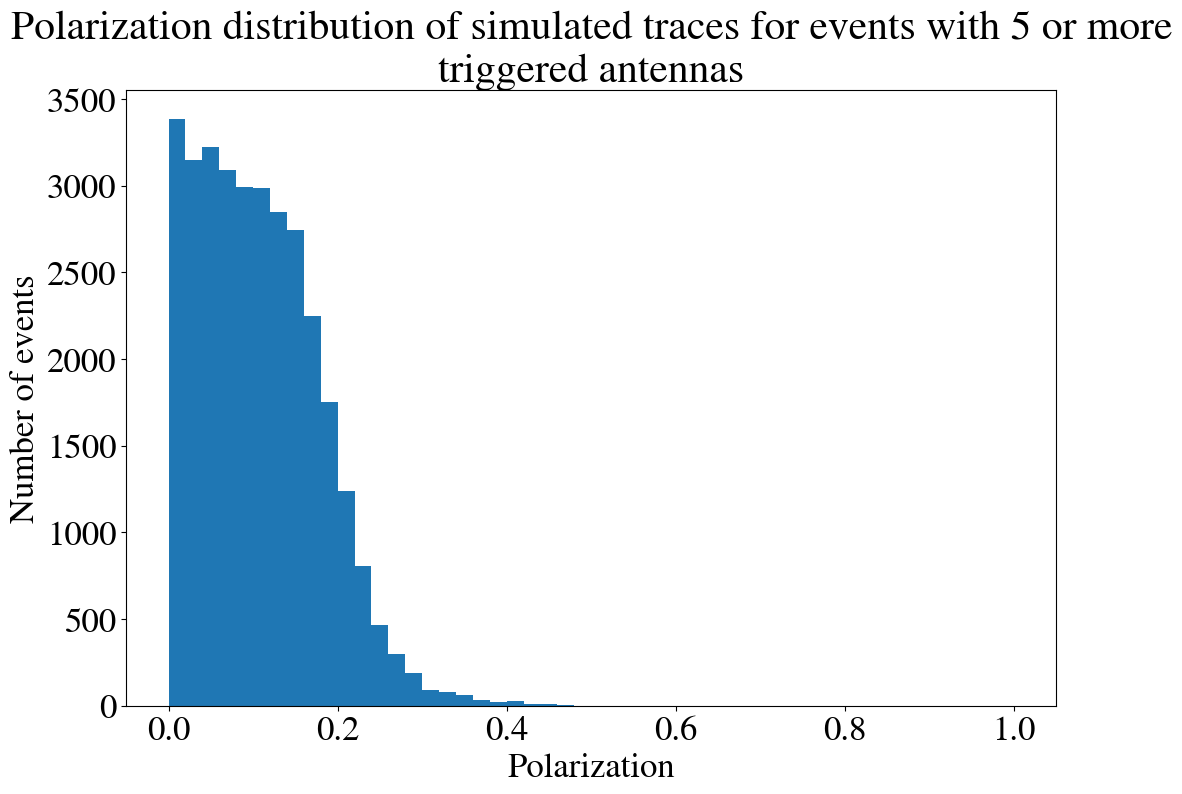

In [31]:
plt.hist(polarization, 
         bins=50, 
         range=(0, 1), 
        #  density=True
         )
plt.xlabel("Polarization")
plt.ylabel("Number of events")
plt.title("Polarization distribution of simulated traces for events with 5 or more triggered antennas",
          wrap=True)

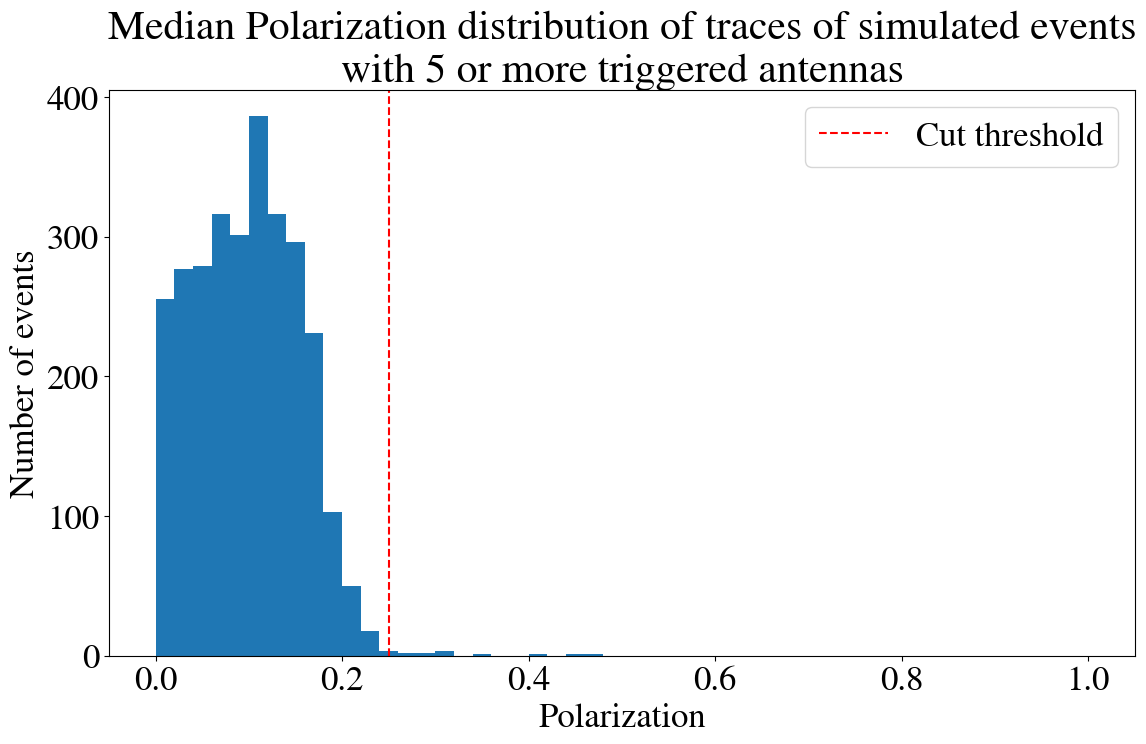

In [32]:
# plt.figure(figsize=(8, 8))
plt.hist(polar_per_event, 
         bins=50, 
         range=(0, 1), 
        #  density=True
         )
plt.xlabel("Polarization")
plt.ylabel("Number of events")
plt.title("Median Polarization distribution of traces of simulated events with 5 or more triggered antennas",
          wrap=True,
        #   fontsize=16
          )
plt.axvline(x=0.25, 
            color='red', 
            linestyle='--', 
            label='Cut threshold'
            )
plt.legend()
plt.tight_layout()
plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/polarization_per_event.png")
plt.show()

## Efficiency of the polarization cut depending on the true energy and zenith angle

In [33]:

efficiency_zenith = np.zeros(len(bins_theta)-1)

for i in range(len(bins_theta)-1):
    mask_bin_theta = (theta_list >= bins_theta[i]) & (theta_list < bins_theta[i+1])
    if len(theta_list[mask_bin_theta]) != 0:
        efficiency_zenith[i] = np.nan_to_num(len(theta_list[(polar_per_event < 0.25) & mask_bin_theta]) / len(theta_list[mask_bin_theta]))

print("Efficiency of the cluster cut depending on the true zenith angle : ", efficiency_zenith)

# Plot a polar plot with incoming events before and after cut (parts of the sky kept afterwards)


Efficiency of the cluster cut depending on the true zenith angle :  [1.         1.         1.         1.         1.         1.
 0.99111111 1.         1.         1.         0.99541284 0.99130435
 0.9744     0.91627907]


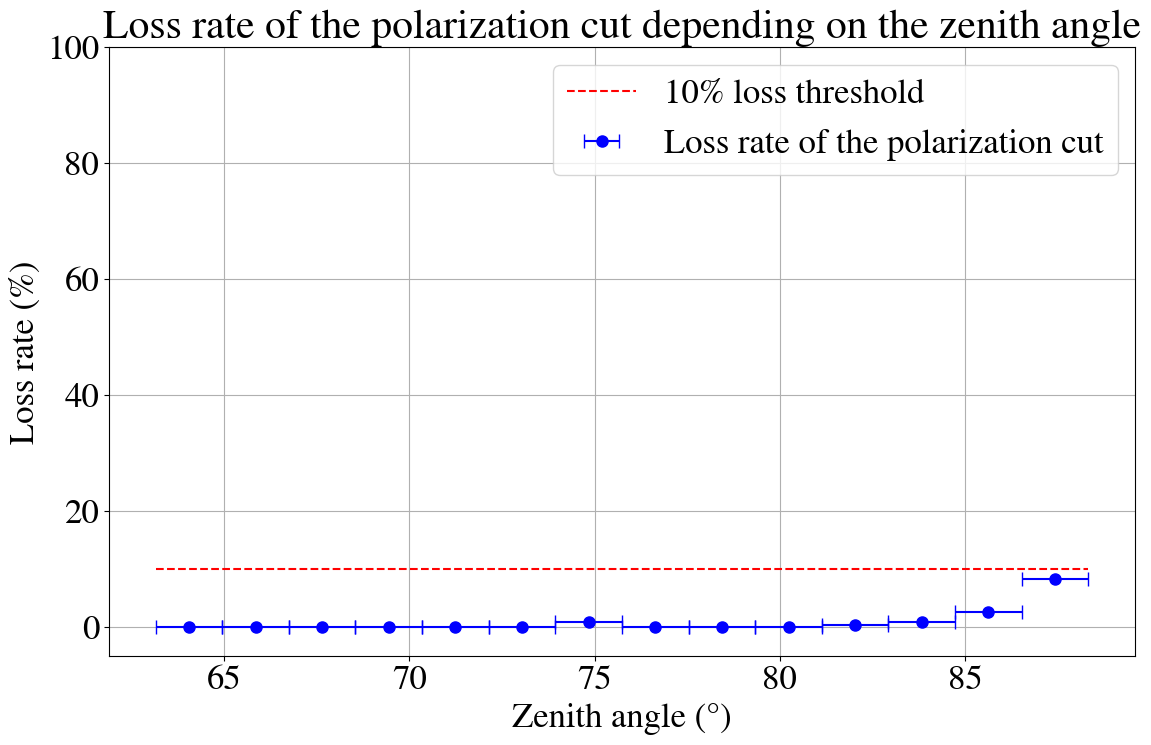

In [34]:
mid_bins_theta = (bins_theta[:-1] + bins_theta[1:]) / 2

plt.errorbar(mid_bins_theta, 
             100*(1-efficiency_zenith),
             xerr=(bins_theta[1:] - bins_theta[:-1]) / 2,
             fmt='o',
             label='Loss rate of the polarization cut',
             color='blue',
             markersize=8,
             capsize=5,
             )
plt.plot(bins_theta,
         np.ones(len(bins_theta))*10,
         color='red',
         linestyle='--',
         label='10% loss threshold',
         )

plt.xlabel('Zenith angle (°)')
plt.ylabel('Loss rate (%)')
plt.ylim(-5, 100)
plt.title('Loss rate of the polarization cut depending on the zenith angle')
plt.grid()
plt.legend()
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/efficiency_polar_zenith.png")
plt.show()

In [35]:

efficiency_energy = np.zeros(len(bins_energy)-1)

for i in range(len(bins_energy)-1):
    mask_bin_energy = (energy >= bins_energy[i]) & (energy < bins_energy[i+1])
    if len(energy[mask_bin_energy]) != 0:
        efficiency_energy[i] = np.nan_to_num(len(energy[(polar_per_event < 0.25) & mask_bin_energy]) / len(energy[mask_bin_energy]))

print("Efficiency of the cluster cut depending on the true energy : ", efficiency_energy)

# Plot a polar plot with incoming events before and after cut (parts of the sky kept afterwards)


Efficiency of the cluster cut depending on the true energy :  [1.         0.93103448 0.97777778 0.98913043 0.98529412 0.98611111
 0.99456522 0.97905759 0.9826087  0.97816594 0.97647059 0.98545455
 0.98561151 0.98776758 0.99399399 0.99375    1.         1.
 1.        ]


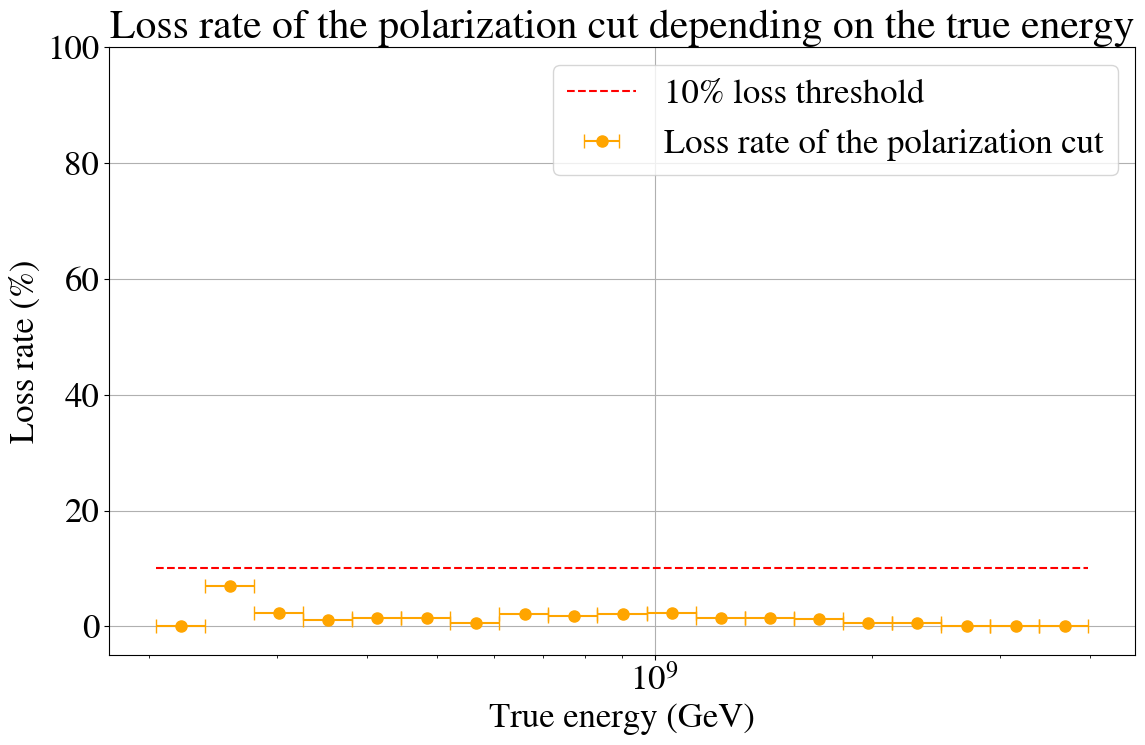

In [36]:
mid_bins_energy = (bins_energy[:-1] + bins_energy[1:]) / 2

plt.errorbar(mid_bins_energy, 
             100*(1-efficiency_energy),
             xerr=(bins_energy[1:] - bins_energy[:-1]) / 2,
             fmt='o',
             label='Loss rate of the polarization cut',
             color='orange',
             markersize=8,
             capsize=5,
             )
plt.plot(bins_energy,
         np.ones(len(bins_energy))*10,
         color='red',
         linestyle='--',
         label='10% loss threshold',
         )

plt.xlabel('True energy (GeV)')
plt.ylabel('Loss rate (%)')
plt.ylim(-5, 100)
plt.xscale('log')
plt.title('Loss rate of the polarization cut depending on the true energy')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/efficiency_polar_energy.png")
plt.show()

## Efficiency 2d

In [37]:
energy_zenith_hist2d = np.histogram2d(energy, 
                                      theta_list, 
                                      bins=(bins_energy, bins_theta), 
                                      )[0]
# no need for weighting here, since this histogram is used for efficiency, so each bin will be divided by itself

energy_zenith_after_SWFcut_hist2d = np.histogram2d(energy[polar_per_event < 1000],
                                                  theta_list[polar_per_event < 1000],
                                                  bins=(bins_energy, bins_theta),
                                                  )[0]

efficiency_energy_zenith = energy_zenith_after_SWFcut_hist2d / energy_zenith_hist2d


/scratch/users/j/jlavoisier/ipykernel_1881654/3511255918.py:12: RuntimeWarning: invalid value encountered in divide
  efficiency_energy_zenith = energy_zenith_after_SWFcut_hist2d / energy_zenith_hist2d


In [38]:
# Measuring the total efficiency folded with expecting flux for each bin

folding_eff = np.load("/pbs/home/j/jlavoisier/pipeline_lab/check_sims/simsGP300NJ_folded_events.npy")[0]

norm = np.sum(folding_eff[np.logical_not( np.isnan(efficiency_energy_zenith) )])

eff_total = np.sum(np.nan_to_num(efficiency_energy_zenith * folding_eff)) / norm
print("Total efficiency of the SWF reconstruction folded with expecting flux : ", eff_total)

Total efficiency of the SWF reconstruction folded with expecting flux :  0.9793740311015734


/scratch/users/j/jlavoisier/ipykernel_1881654/3072038350.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Flux-weighted loss : {:.2f}%'.format((1-eff_total)*100),


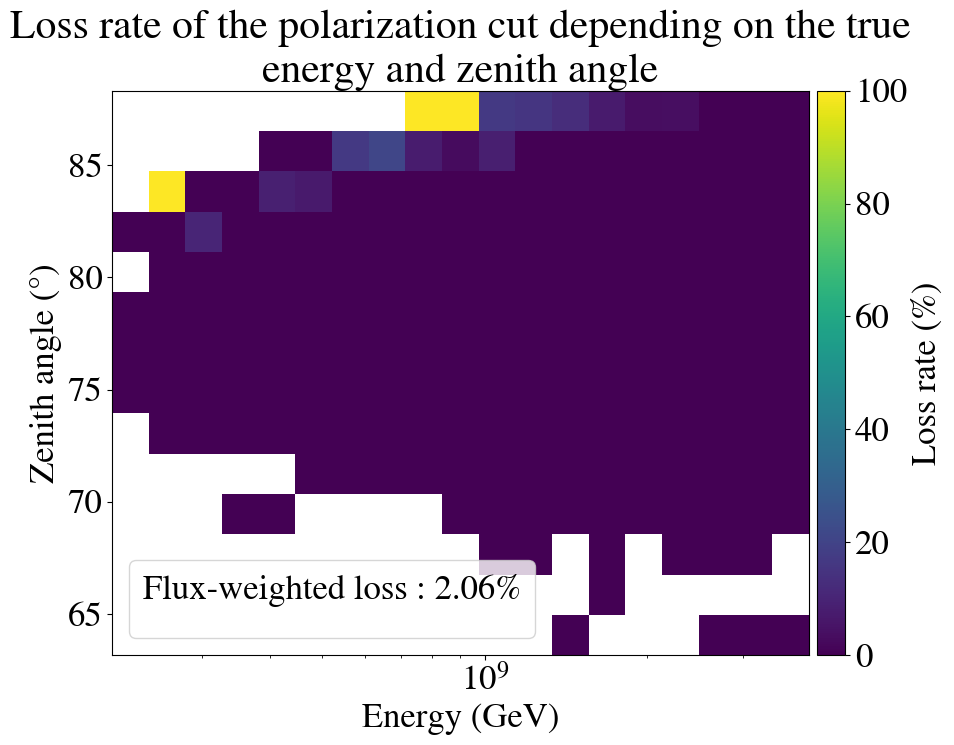

In [42]:
loss_rate = (1-efficiency_energy_zenith)*100
plt.figure(figsize=(10, 8))
X, Y = np.meshgrid(bins_energy, bins_theta)
im = plt.pcolormesh(X, 
                Y, 
                loss_rate.T, 
                cmap="viridis",
                # norm=mpl.colors.LogNorm(vmin=folded_events.min(), vmax=folded_events.max())
                )
plt.colorbar(im, label='Loss rate (%)',
             pad=0.01)
plt.xlabel('Energy (GeV)')
plt.xscale('log')
plt.ylabel('Zenith angle (°)')
plt.title('Loss rate of the polarization cut depending on the true energy and zenith angle',
          wrap=True
          )
plt.legend(title='Flux-weighted loss : {:.2f}%'.format((1-eff_total)*100),
           loc='lower left'
           )
plt.tight_layout()
plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/efficiency_polarization_true_energy_zenith.png")
plt.show()